# TP : Apprentissage Non Supervisé (exercice)
## Dataset : Wine Quality - vins rouges portugais (OpenML)

**Objectifs :**
- Appliquer K-Means, DBSCAN, Isolation Forest et CAH sur des données réelles
- Optimiser les hyperparamètres (k, eps/min_samples, contamination)
- Qualifier et valider les clusters obtenus

**Datamap (dictionnaire des données) :** 11 mesures physico-chimiques par échantillon de vin.

| Colonne | Description |
|---|---|
| fixed acidity | Acidité fixe (acides non volatils) |
| volatile acidity | Acidité volatile (acide acétique, cause du goût de vinaigre en excès) |
| citric acid | Acide citrique |
| residual sugar | Sucre résiduel après fermentation |
| chlorides | Teneur en sel (chlorures) |
| free sulfur dioxide | SO₂ libre (protège contre l'oxydation et les microbes) |
| total sulfur dioxide | SO₂ total (libre + lié) |
| density | Densité du vin |
| pH | Acidité/basicité sur une échelle 0-14 |
| sulphates | Sulfates (additif antimicrobien) |
| alcohol | Teneur en alcool (%) |

**Note :** la note de qualité (`quality`, 3 à 8) est mise de côté et n'est utilisée qu'à la toute fin, pour valider les clusters obtenus.

> **Version exercice** : les cellules marquées `# TODO` sont à compléter. Le reste (imports, chargement des données, affichages) est déjà fourni.
> Installe les dépendances une seule fois avec `pip install -r requirements.txt` depuis `cours_ml/todo/` (voir le README de ce dossier). Ce TP s'inspire de `cours_ml/01_non_supervise/tp_non_supervise.ipynb` (même méthode, données différentes et plus volumineuses : 1599 vins contre 178).

---
## 0. Installation & Imports

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


---
## 1. Chargement des données

In [57]:
# Wine Quality (vins rouges) : 1599 echantillons, 11 mesures physico-chimiques + une note de qualite (3-8)
# Chargement depuis OpenML (dataset public, aucune authentification requise)
wine = fetch_openml(name='wine-quality-red', version='active', as_frame=True, parser='auto')
df_raw = wine.frame.drop(columns=['class']).astype(float)
quality = wine.frame['class'].astype(int)  # note de qualite, gardee a part pour la validation (section 9)

print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
df_raw.head()


Dimensions : 1599 lignes x 11 colonnes


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [58]:
df_raw.describe().round(2)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90


In [59]:
print(df_raw.isnull().sum().sum(), "valeurs manquantes")

0 valeurs manquantes


---
## 2. Prétraitement

Les algorithmes de clustering (surtout K-Means et DBSCAN) sont sensibles aux échelles.
On normalise toutes les features avec `StandardScaler` (moyenne=0, écart-type=1).

In [60]:
# TODO : standardiser les features (moyenne=0, ecart-type=1)
# Indice : StandardScaler().fit_transform(df_raw), puis remettre en DataFrame avec les memes colonnes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_raw)

print("Moyenne après scaling :", X_scaled.mean().round(6).max())
print("Std après scaling    :", X_scaled.std().round(2).min())


Moyenne après scaling : -0.0
Std après scaling    : 1.0


### Réduction dimensionnelle pour la visualisation (PCA 2D)
On réduit à 2 composantes uniquement pour visualiser : les modèles tournent sur les 11 features.

Variance expliquée : PC1=28.2%, PC2=17.5%
Total : 45.7%


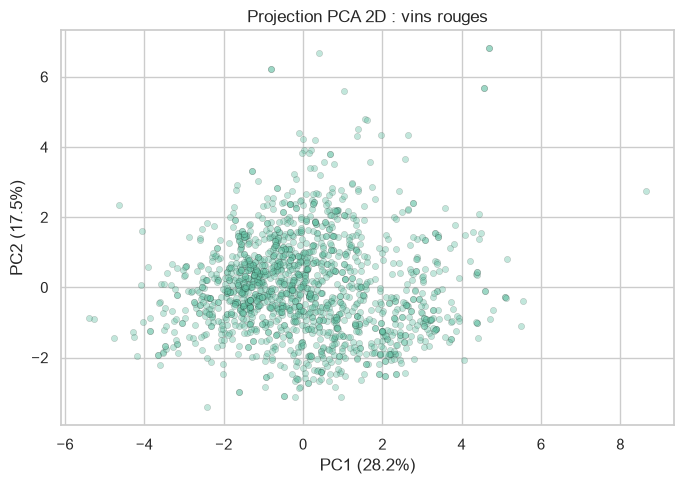

In [61]:
# TODO : reduire a 2 composantes avec PCA pour la visualisation
# Indice : PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée : PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total : {sum(pca.explained_variance_ratio_):.1%}")

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, edgecolors='k', linewidths=0.2, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Projection PCA 2D : vins rouges')
plt.tight_layout()
plt.show()


---
## 3. K-Means

### 3.1 Optimisation du nombre de clusters (k)
On teste k de 2 à 10 et on compare :
- **Inertie** (elbow method) : somme des distances au centroïde
- **Score de silhouette** : mesure de compacité et séparation

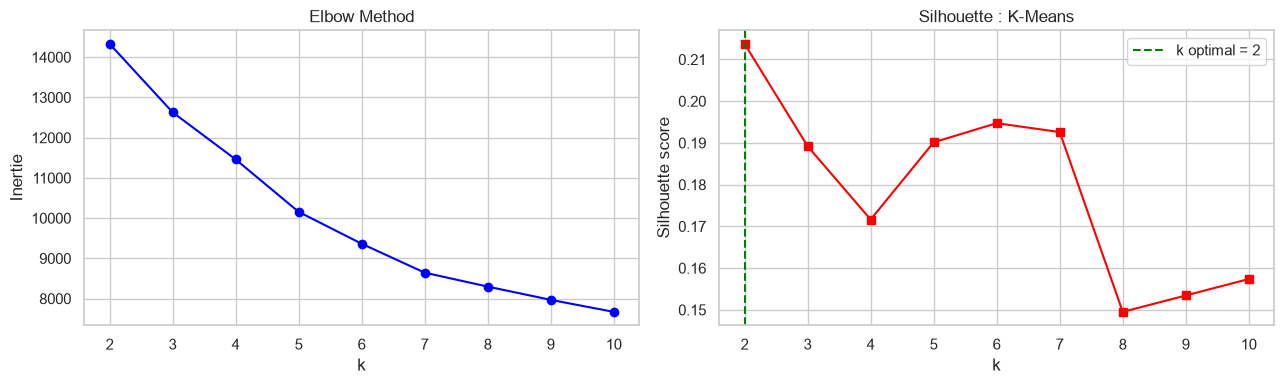

k optimal (silhouette max) : 2 → score = 0.2137


In [62]:
K_range = range(2, 11)
inertias = []
silhouettes_kmeans = []

for k in K_range:
    # TODO : entrainer un KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10), stocker l'inertie et le score de silhouette
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes_kmeans.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes_kmeans, 'rs-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette : K-Means')

best_k = list(K_range)[np.argmax(silhouettes_kmeans)]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'k optimal = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"k optimal (silhouette max) : {best_k} → score = {max(silhouettes_kmeans):.4f}")


### 3.2 Entraînement avec k optimal

In [63]:
# TODO : entrainer le KMeans final avec k=best_k et recuperer les labels
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = km_best.fit_predict(X_scaled)

print(f"Silhouette K-Means (k={best_k}) : {silhouette_score(X_scaled, labels_kmeans):.4f}")
print("Distribution des clusters :")
print(pd.Series(labels_kmeans).value_counts().sort_index())


Silhouette K-Means (k=2) : 0.2137
Distribution des clusters :
0     590
1    1009
Name: count, dtype: int64


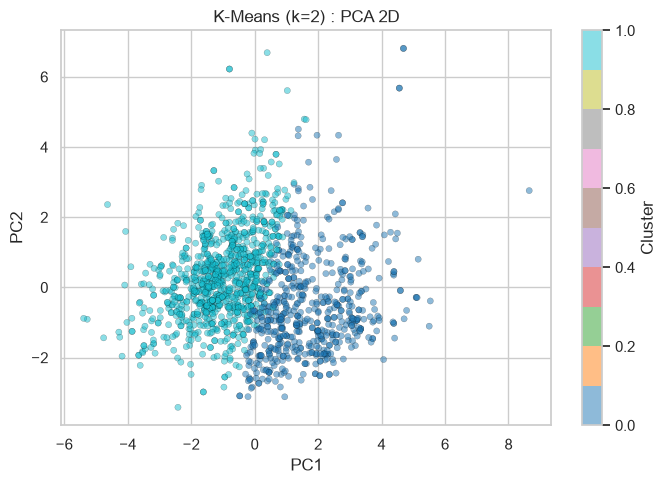

In [64]:
# Visualisation PCA
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='tab10', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means (k={best_k}) : PCA 2D')
plt.tight_layout()
plt.show()


### 3.3 Silhouette plot par échantillon

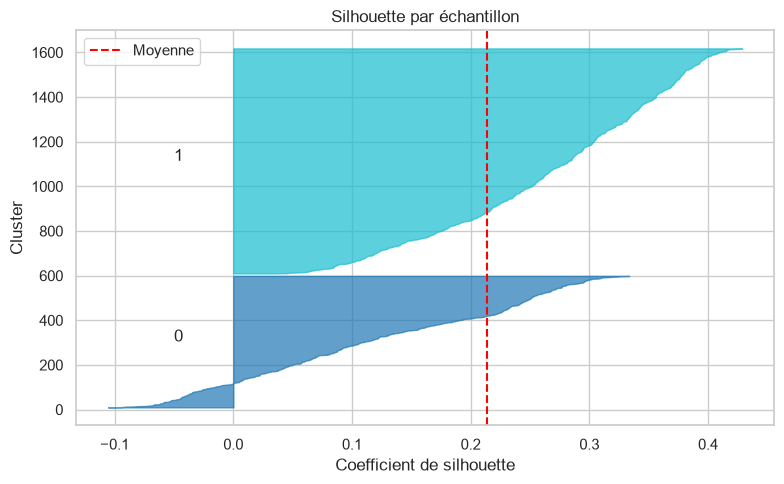

In [65]:
sample_silhouette_values = silhouette_samples(X_scaled, labels_kmeans)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for i in range(best_k):
    ith_values = sample_silhouette_values[labels_kmeans == i]
    ith_values.sort()
    size_i = ith_values.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values, facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, labels_kmeans), color='red', linestyle='--', label='Moyenne')
ax.set_xlabel('Coefficient de silhouette')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette par échantillon')
ax.legend()
plt.tight_layout()
plt.show()


---
## 4. DBSCAN

DBSCAN regroupe les points denses et marque les points isolés comme **bruit** (label = -1).
Deux hyperparamètres clés :
- `eps` : rayon de voisinage
- `min_samples` : nombre minimum de voisins pour former un cluster dense

In [66]:
from itertools import product

eps_values = np.arange(0.5, 3.0, 0.25)
min_samples_values = [3, 5, 7, 10]

results_dbscan = []

for eps, min_s in product(eps_values, min_samples_values):
    # TODO : entrainer un DBSCAN(eps=eps, min_samples=min_s) et recuperer les labels
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    if n_clusters >= 2:
        sil = silhouette_score(X_scaled, labels)
        results_dbscan.append({'eps': eps, 'min_samples': min_s, 'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil})

df_dbscan_results = pd.DataFrame(results_dbscan).sort_values('silhouette', ascending=False)
print(f"{len(df_dbscan_results)} configurations valides (≥2 clusters)")
df_dbscan_results.head(10)


36 configurations valides (≥2 clusters)


,eps,min_samples,n_clusters,n_noise,silhouette
33,2.75,5,2,44,0.478472
34,2.75,7,2,47,0.474346
35,2.75,10,2,47,0.474346
32,2.75,3,4,31,0.465253
28,2.50,3,4,42,0.437952
31,2.50,10,2,69,0.427257
26,2.25,7,2,94,0.395562
27,2.25,10,2,104,0.383560
22,2.00,7,2,143,0.343749
21,2.00,5,3,126,0.259836


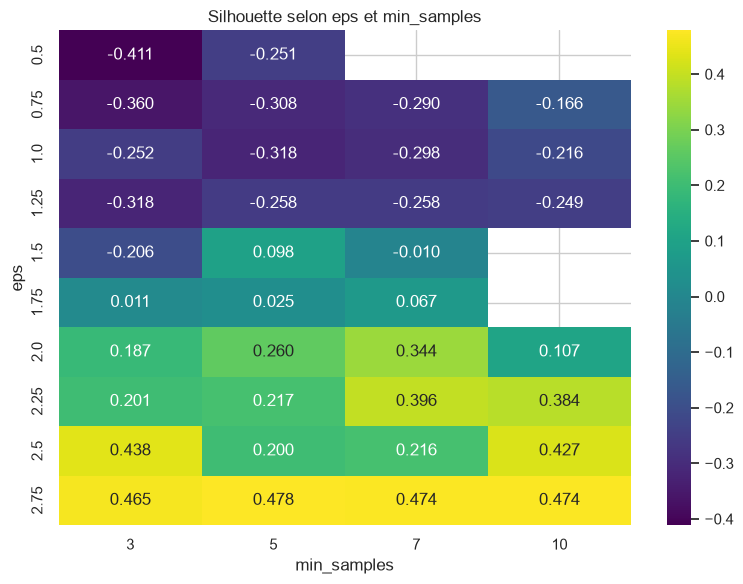

In [67]:
# Heatmap silhouette
pivot = df_dbscan_results.pivot_table(index='eps', columns='min_samples', values='silhouette', aggfunc='max')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title('Silhouette selon eps et min_samples')
plt.tight_layout()
plt.show()


### 4.2 Entraînement avec les meilleurs paramètres

In [68]:
best_dbscan = df_dbscan_results.iloc[0]
print(f"Meilleurs paramètres : eps={best_dbscan['eps']:.2f}, min_samples={int(best_dbscan['min_samples'])}")
print(f"Clusters : {int(best_dbscan['n_clusters'])} | Bruit : {int(best_dbscan['n_noise'])} points | Silhouette : {best_dbscan['silhouette']:.4f}")

# TODO : entrainer le DBSCAN final avec les meilleurs parametres et recuperer les labels
db_best = DBSCAN(eps=best_dbscan['eps'], min_samples=int(best_dbscan['min_samples']))
labels_dbscan = db_best.fit_predict(X_scaled)


Meilleurs paramètres : eps=2.75, min_samples=5
Clusters : 2 | Bruit : 44 points | Silhouette : 0.4785


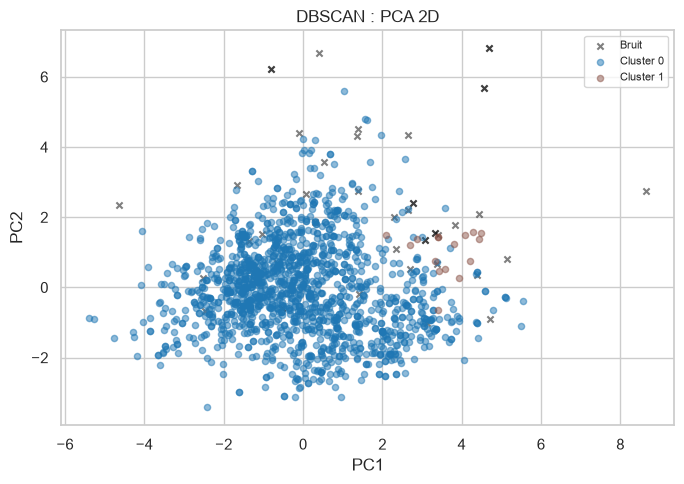

In [69]:
plt.figure(figsize=(7, 5))
unique_labels = sorted(set(labels_dbscan))
cmap = plt.cm.tab10

for label in unique_labels:
    mask = labels_dbscan == label
    color = 'black' if label == -1 else cmap(label / max(1, best_dbscan['n_clusters']))
    marker = 'x' if label == -1 else 'o'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], marker=marker, alpha=0.5, s=20,
                label=f'Bruit' if label == -1 else f'Cluster {label}')

plt.legend(fontsize=8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN : PCA 2D')
plt.tight_layout()
plt.show()


---
## 5. Isolation Forest

Isolation Forest est un algorithme de **détection d'anomalies** :
il isole les points atypiques (vins aux propriétés chimiques inhabituelles) en construisant des arbres de partitionnement aléatoire.

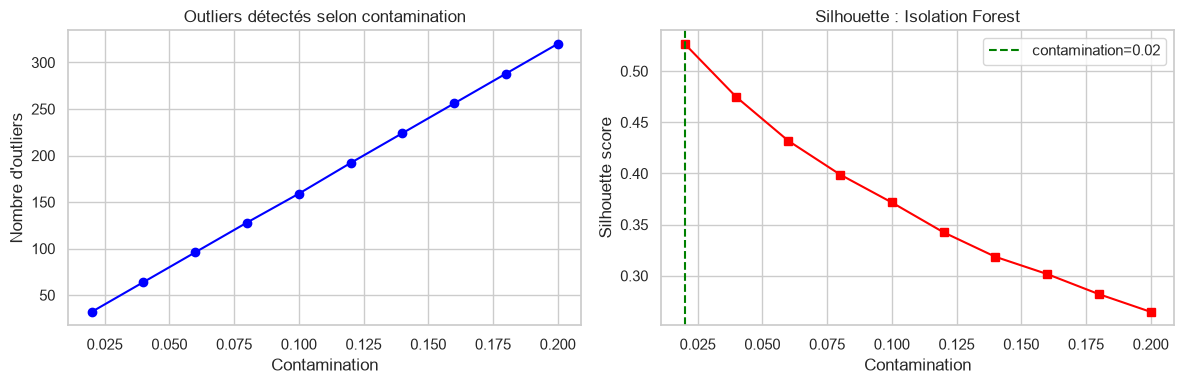

Contamination optimale : 0.02 → silhouette = 0.5267


In [70]:
contamination_values = np.arange(0.02, 0.21, 0.02)
results_if = []

for cont in contamination_values:
    # TODO : entrainer un IsolationForest(contamination=cont, random_state=RANDOM_STATE) et recuperer les predictions (1=inlier, -1=outlier)
    iso = IsolationForest(contamination=cont, random_state=RANDOM_STATE)
    preds = iso.fit_predict(X_scaled)
    n_outliers = (preds == -1).sum()

    if len(set(preds)) == 2:
        sil = silhouette_score(X_scaled, preds)
        results_if.append({'contamination': round(cont, 2), 'n_outliers': n_outliers, 'pct_outliers': round(cont * 100, 1), 'silhouette': sil})

df_if_results = pd.DataFrame(results_if)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_if_results['contamination'], df_if_results['n_outliers'], 'bo-')
axes[0].set_xlabel('Contamination')
axes[0].set_ylabel("Nombre d'outliers")
axes[0].set_title('Outliers détectés selon contamination')

axes[1].plot(df_if_results['contamination'], df_if_results['silhouette'], 'rs-')
axes[1].set_xlabel('Contamination')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette : Isolation Forest')

best_cont = df_if_results.loc[df_if_results['silhouette'].idxmax(), 'contamination']
axes[1].axvline(best_cont, color='green', linestyle='--', label=f'contamination={best_cont}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Contamination optimale : {best_cont} → silhouette = {df_if_results['silhouette'].max():.4f}")


### 5.2 Détection d'anomalies avec contamination optimale

In [71]:
# TODO : entrainer l'Isolation Forest final avec contamination=best_cont
iso_best = IsolationForest(contamination=best_cont, random_state=RANDOM_STATE)
labels_if = iso_best.fit_predict(X_scaled)  # 1 = normal, -1 = anomalie
scores_if = iso_best.decision_function(X_scaled)  # score d'anomalie (plus bas = plus anormal)

n_outliers = (labels_if == -1).sum()
print(f"Outliers détectés : {n_outliers} ({n_outliers/len(labels_if):.1%} du dataset)")
print(f"Silhouette : {silhouette_score(X_scaled, labels_if):.4f}")


Outliers détectés : 32 (2.0% du dataset)
Silhouette : 0.5267


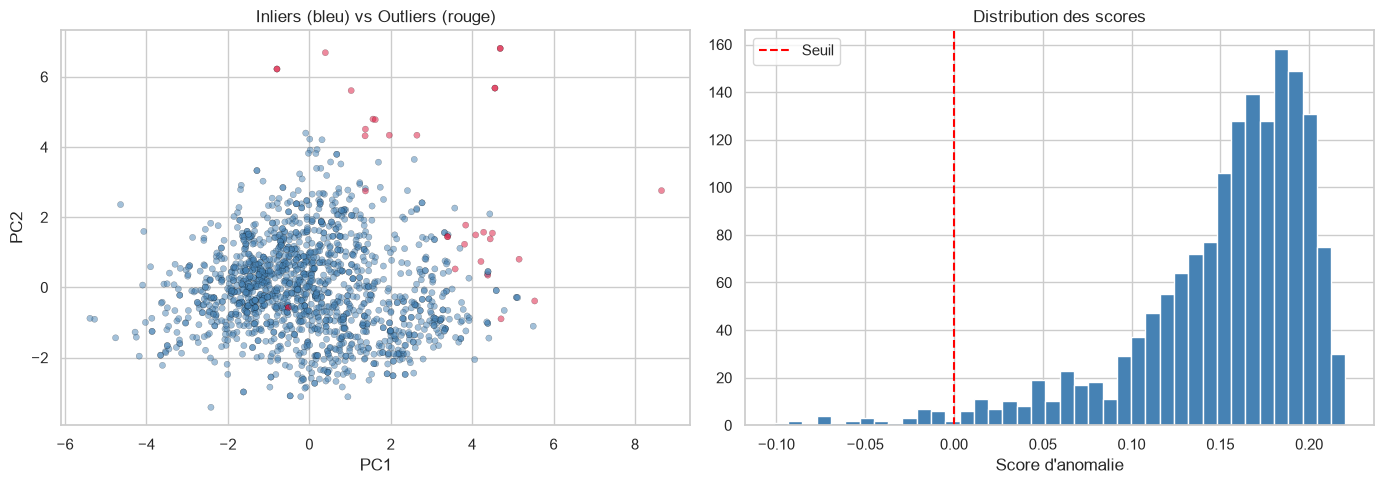

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_if = ['steelblue' if l == 1 else 'crimson' for l in labels_if]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_if, alpha=0.5, s=20, edgecolors='k', linewidths=0.2)
axes[0].set_title('Inliers (bleu) vs Outliers (rouge)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].hist(scores_if, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(np.percentile(scores_if, best_cont * 100), color='red', linestyle='--', label='Seuil')
axes[1].set_xlabel('Score d\'anomalie')
axes[1].set_title('Distribution des scores')
axes[1].legend()

plt.tight_layout()
plt.show()


### 5.3 Isolation Forest + K-Means : clustering des inliers
On peut combiner les deux : filtrer les anomalies avec Isolation Forest, puis clustériser les inliers.

Silhouette K-Means sur inliers : 0.2107 (vs 0.2137 sur tout le dataset)


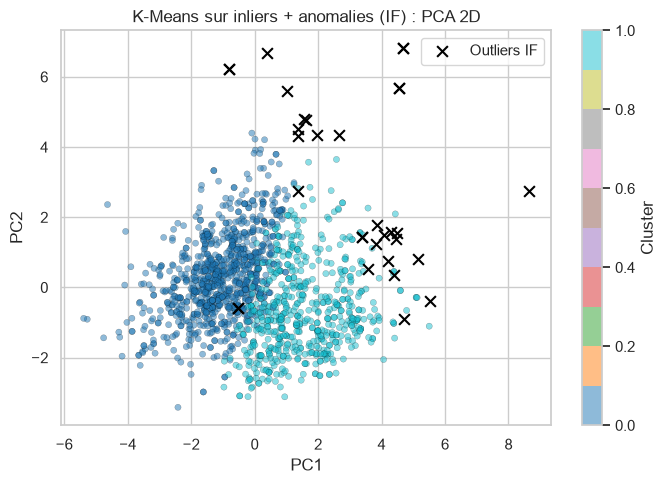

In [73]:
mask_inliers = labels_if == 1
X_inliers = X_scaled[mask_inliers]
X_pca_inliers = X_pca[mask_inliers]

# TODO : entrainer un KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10) sur les inliers uniquement
km_inliers = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_combined = km_inliers.fit_predict(X_inliers)

sil_combined = silhouette_score(X_inliers, labels_combined)
print(f"Silhouette K-Means sur inliers : {sil_combined:.4f} (vs {silhouette_score(X_scaled, labels_kmeans):.4f} sur tout le dataset)")

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca_inliers[:, 0], X_pca_inliers[:, 1], c=labels_combined, cmap='tab10', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.scatter(X_pca[~mask_inliers, 0], X_pca[~mask_inliers, 1], marker='x', color='black', s=60, label='Outliers IF', zorder=5)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means sur inliers + anomalies (IF) : PCA 2D')
plt.tight_layout()
plt.show()


---
## 6. CAH : Clustering Agglomératif Hiérarchique

La CAH construit un arbre (dendrogramme) en fusionnant itérativement les points les plus proches.
Avantages : pas besoin de spécifier k à l'avance, on peut couper l'arbre à différents niveaux.

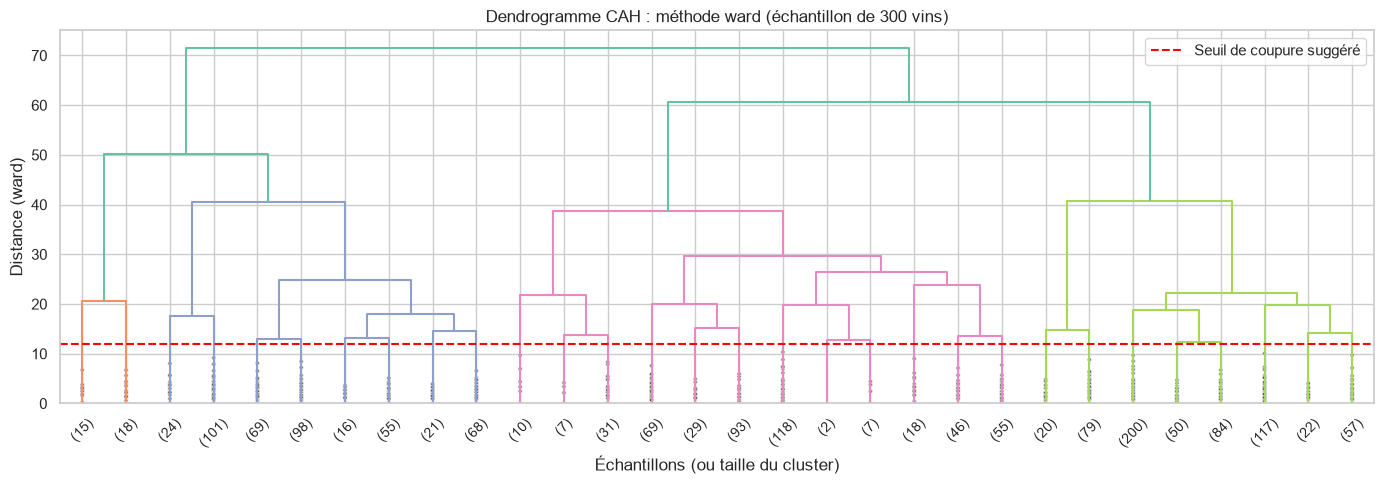

In [74]:
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.cluster import AgglomerativeClustering

# TODO : calculer la matrice de linkage ward sur X_scaled (sur un echantillon de 300 points pour la lisibilite du dendrogramme)
# Indice : scipy_linkage(X_scaled.sample(300, random_state=RANDOM_STATE), method='ward')
Z = scipy_linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.axhline(y=12, color='red', linestyle='--', label='Seuil de coupure suggéré')
plt.xlabel('Échantillons (ou taille du cluster)')
plt.ylabel('Distance (ward)')
plt.title('Dendrogramme CAH : méthode ward (échantillon de 300 vins)')
plt.legend()
plt.tight_layout()
plt.show()


### 6.2 Optimisation : linkage × n_clusters via silhouette

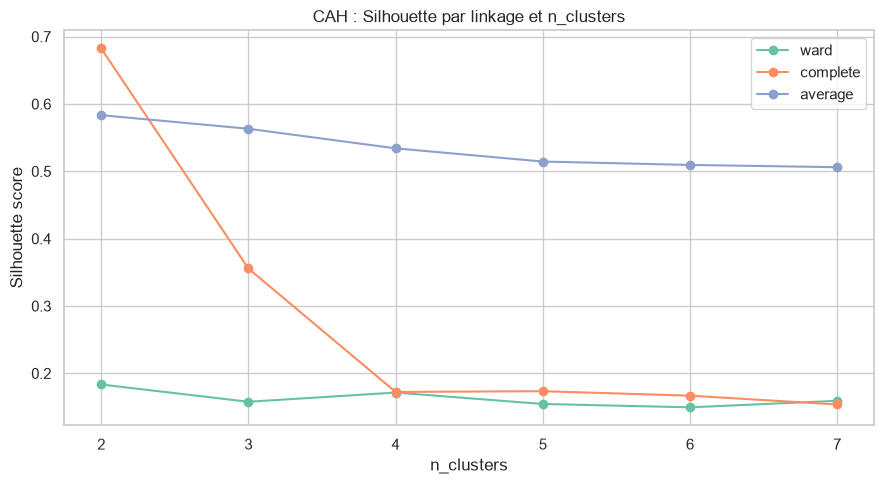

Meilleure config : linkage=complete, n_clusters=2 → silhouette=0.6825


In [75]:
linkage_methods = ['ward', 'complete', 'average']
n_clusters_range = range(2, 8)
results_cah = []

for method in linkage_methods:
    for n in n_clusters_range:
        # TODO : entrainer un AgglomerativeClustering(n_clusters=n, linkage=method) et calculer le silhouette score
        cah = AgglomerativeClustering(n_clusters=n, linkage=method)
        labels = cah.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        results_cah.append({'linkage': method, 'n_clusters': n, 'silhouette': sil})

df_cah_results = pd.DataFrame(results_cah)

plt.figure(figsize=(9, 5))
for method in linkage_methods:
    subset = df_cah_results[df_cah_results['linkage'] == method]
    plt.plot(subset['n_clusters'], subset['silhouette'], marker='o', label=method)

plt.xlabel('n_clusters')
plt.ylabel('Silhouette score')
plt.title('CAH : Silhouette par linkage et n_clusters')
plt.legend()
plt.tight_layout()
plt.show()

best_cah = df_cah_results.loc[df_cah_results['silhouette'].idxmax()]
print(f"Meilleure config : linkage={best_cah['linkage']}, n_clusters={int(best_cah['n_clusters'])} → silhouette={best_cah['silhouette']:.4f}")


### 6.3 Entraînement avec la config optimale

Silhouette CAH : 0.6825
Distribution des clusters :
0    1597
1       2
Name: count, dtype: int64


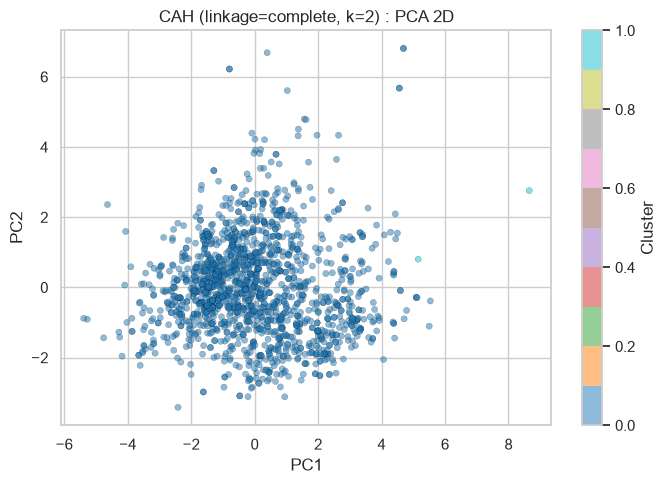

In [76]:
# TODO : entrainer le CAH final avec la config optimale (best_cah)
cah_best = AgglomerativeClustering(n_clusters=int(best_cah['n_clusters']), linkage=best_cah['linkage'])
labels_cah = cah_best.fit_predict(X_scaled)

print(f"Silhouette CAH : {silhouette_score(X_scaled, labels_cah):.4f}")
print("Distribution des clusters :")
print(pd.Series(labels_cah).value_counts().sort_index())

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_cah, cmap='tab10', alpha=0.5, edgecolors='k', linewidths=0.2, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f"CAH (linkage={best_cah['linkage']}, k={int(best_cah['n_clusters'])}) : PCA 2D")
plt.tight_layout()
plt.show()


---
## 7. Qualification des clusters (K-Means)

La qualification consiste à **caractériser chaque cluster** : quelles features le distinguent ?
On travaille sur les résultats K-Means qui produisent des clusters de taille équilibrée.

In [77]:
df_qualified = df_raw.copy()
df_qualified['cluster_kmeans'] = labels_kmeans

# TODO : calculer la moyenne de chaque feature par cluster (non normalisee, pour rester interpretable)
# Indice : df_qualified.groupby('cluster_kmeans').mean()
profile = df_qualified.groupby('cluster_kmeans').mean()
profile


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
cluster_kmeans,,,,,,,,,,,
0,9.922712,0.413907,0.462881,2.765763,0.099900,13.410169,39.388136,0.997689,3.201847,0.748237,10.607401
1,7.382260,0.594430,0.158761,2.406095,0.080196,17.316155,50.607532,0.996195,3.375005,0.605471,10.315147


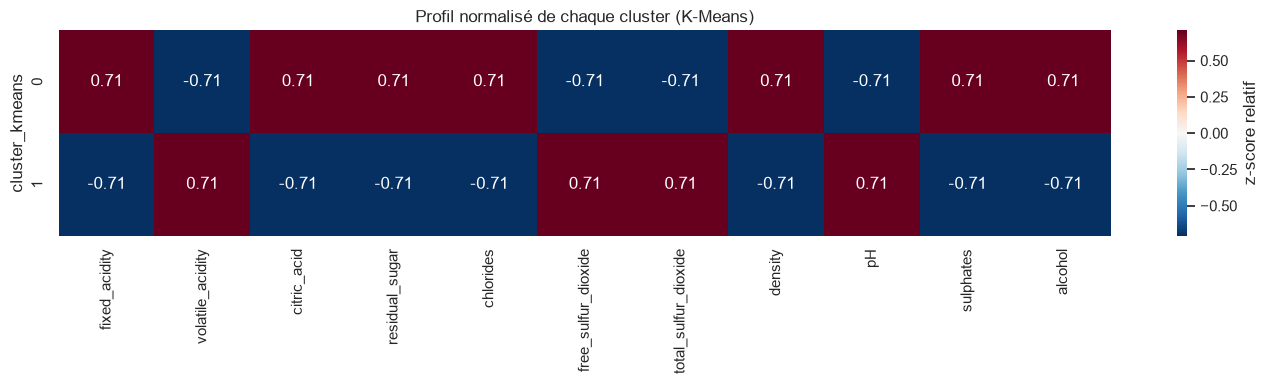

In [78]:
profile_z = (profile - profile.mean()) / profile.std()

plt.figure(figsize=(14, 4))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar_kws={'label': 'z-score relatif'})
plt.title('Profil normalisé de chaque cluster (K-Means)')
plt.tight_layout()
plt.show()


In [79]:
# Top features discriminantes par cluster (écart à la moyenne globale)
global_mean = df_raw.mean()

for cluster_id in sorted(df_qualified['cluster_kmeans'].unique()):
    # TODO : calculer l'ecart en % entre la moyenne du cluster et la moyenne globale, trier par ecart absolu decroissant
    cluster_mean = df_qualified[df_qualified['cluster_kmeans'] == cluster_id].mean()
    diff = ((cluster_mean - global_mean) / global_mean * 100).abs().sort_values(ascending=False)
    print(f"\n--- Cluster {cluster_id} ({(labels_kmeans == cluster_id).sum()} vins) ---")
    print(diff.head(5).to_string())



--- Cluster 0 (590 vins) ---
citric_acid             70.820302
volatile_acidity        21.581907
fixed_acidity           19.268564
free_sulfur_dioxide     15.526075
total_sulfur_dioxide    15.235621

--- Cluster 1 (1009 vins) ---
citric_acid             41.411277
volatile_acidity        12.619748
fixed_acidity           11.267049
free_sulfur_dioxide      9.078676
total_sulfur_dioxide     8.908837


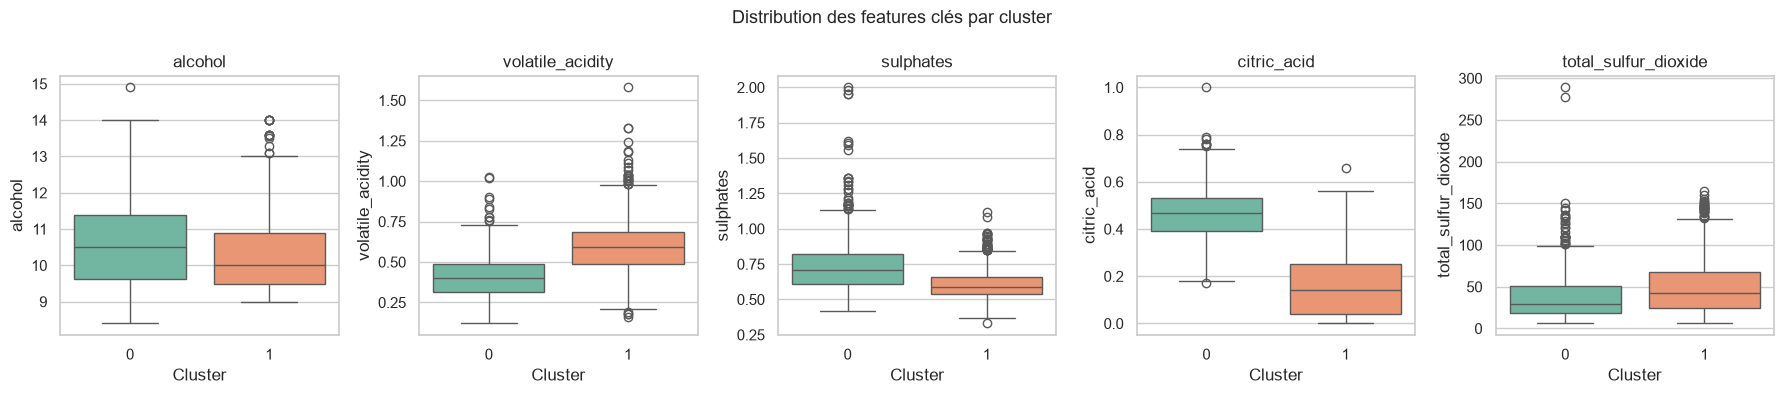

In [80]:
# Boxplots des features les plus discriminantes
top_features = ['alcohol', 'volatile_acidity', 'sulphates', 'citric_acid', 'total_sulfur_dioxide']

fig, axes = plt.subplots(1, len(top_features), figsize=(18, 4))
for ax, feat in zip(axes, top_features):
    sns.boxplot(data=df_qualified, x='cluster_kmeans', y=feat, ax=ax, hue='cluster_kmeans', legend=False)
    ax.set_title(feat)
    ax.set_xlabel('Cluster')

plt.suptitle('Distribution des features clés par cluster', fontsize=13)
plt.tight_layout()
plt.show()


---
## 8. Comparaison des modèles

In [81]:
# TODO : construire le tableau recapitulatif : pour chaque modele, ses parametres optimaux, son nombre de
# clusters/outliers et son score de silhouette (voir les variables calculees dans les sections precedentes)
results_summary = [
    {'model': 'K-Means', 'params': f'k={best_k}', 'n_clusters': best_k, 'n_outliers': 0, 'silhouette': max(silhouettes_kmeans)},
    {'model': 'DBSCAN', 'params': f'eps={best_dbscan["eps"]:.2f}, min_samples={int(best_dbscan["min_samples"])}', 
     'n_clusters': int(best_dbscan['n_clusters']), 'n_outliers': int(best_dbscan['n_noise']), 'silhouette': best_dbscan['silhouette']},
    {'model': 'Isolation Forest', 'params': f'contamination={best_cont}', 
     'n_clusters': 0, 'n_outliers': n_outliers, 'silhouette': silhouette_score(X_scaled, labels_if)},
    {'model': 'CAH', 'params': f'linkage={best_cah["linkage"]}, n_clusters={int(best_cah["n_clusters"])}', 
     'n_clusters': int(best_cah['n_clusters']), 'n_outliers': 0, 'silhouette': best_cah['silhouette']}
]

df_summary = pd.DataFrame(results_summary)
df_summary


,model,params,n_clusters,n_outliers,silhouette
0,K-Means,k=2,2,0,0.213730
1,DBSCAN,"eps=2.75, min_samples=5",2,44,0.478472
2,Isolation Forest,contamination=0.02,0,32,0.526664
3,CAH,"linkage=complete, n_clusters=2",2,0,0.682483


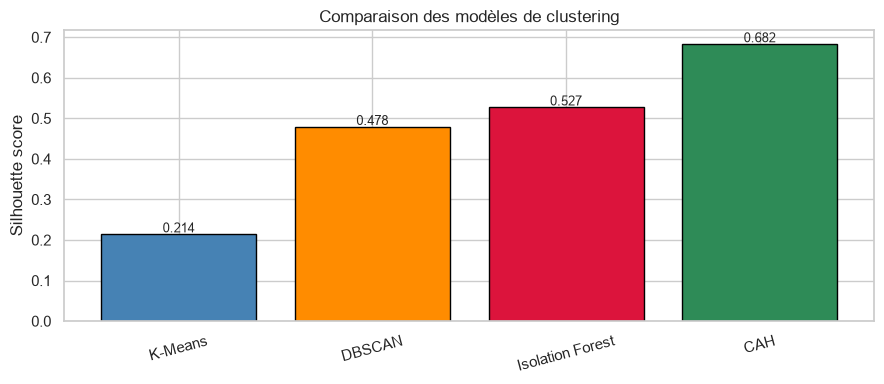

In [85]:
plt.figure(figsize=(9, 4))
bars = plt.bar(df_summary['model'], df_summary['silhouette'], color=['steelblue', 'darkorange', 'crimson', 'seagreen', 'purple'], edgecolor='k')
for bar, val in zip(bars, df_summary['silhouette']):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.3f}', ha='center', fontsize=9)
plt.ylabel('Silhouette score')
plt.title('Comparaison des modèles de clustering')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


---
## 9. Validation : retrouve-t-on des groupes de qualité cohérents ?

Il n'y a pas de vraie étiquette "type de vin" ici, mais chaque vin a une **note de qualité** (3 à 8) mise de côté au chargement.
On la regroupe en 3 paliers (bas/moyen/haut) et on vérifie si les clusters K-Means recoupent ces paliers.
C'est une validation plus faible qu'une vraie étiquette de classe, mais un signal utile sur la pertinence du clustering.

In [87]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# TODO : regrouper `quality` en 3 paliers ('bas' <=4, 'moyen' 5-6, 'haut' >=7), puis calculer ARI et NMI
# entre ces paliers et labels_kmeans
# Indice : pd.cut(quality, bins=[0, 4, 6, 10], labels=['bas', 'moyen', 'haut'])
quality_tier = pd.cut(quality, bins=[0, 4, 6, 10], labels=['bas', 'moyen', 'haut'])
ari = adjusted_rand_score(quality_tier, labels_kmeans)
nmi = normalized_mutual_info_score(quality_tier, labels_kmeans)

print(f"ARI : {ari:.4f}")
print(f"NMI : {nmi:.4f}")
print("\nARI=1 et NMI=1 = clustering parfaitement aligné avec les paliers de qualité")


ARI : 0.0660
NMI : 0.0445

ARI=1 et NMI=1 = clustering parfaitement aligné avec les paliers de qualité


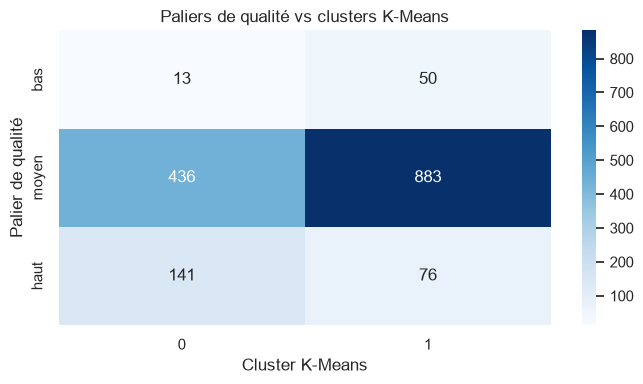

In [88]:
# Table croisée : palier de qualité vs cluster K-Means
ct = pd.crosstab(quality_tier, labels_kmeans)

plt.figure(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Cluster K-Means')
plt.ylabel('Palier de qualité')
plt.title('Paliers de qualité vs clusters K-Means')
plt.tight_layout()
plt.show()


---
## 10. Conclusion

| Critère | K-Means | DBSCAN | Isolation Forest | CAH |
|---|---|---|---|---|
| Type | Partitionnel | Densité | Détection d'anomalies | Hiérarchique |
| Nombre de clusters | Fixé (k) | Découvert automatiquement | 2 (normal/anomalie) | Fixé (coupe du dendrogramme) |
| Sensible aux outliers | Oui | Non (les isole) | C'est son objectif | Oui |
| Forme des clusters | Convexe | Arbitraire | - | Convexe (linkage ward) |

**À retenir :**
- Standardiser avant tout algorithme basé sur des distances.
- La silhouette guide le choix des hyperparamètres, mais reste indicative : croiser avec une interprétation métier.
- Sur ce dataset (1599 vins, 11 variables physico-chimiques), les paliers de qualité ne sont qu'un signal faible de validation : le clustering capture surtout la structure chimique, pas directement la qualité perçue.

---
## Session à rendre

Cette section est à compléter et à rendre à l'issue du TP. Réponds à chaque question dans la
cellule *Réponse* juste en dessous, à partir des résultats que **tu as toi-même obtenus** en
réalisant ce notebook (il n'y a pas de réponse générique valable pour tout le monde : les valeurs
numériques, choix d'hyperparamètres et graphiques dépendent de ton exécution).

**Q1.** Combien de clusters k as-tu retenu pour K-Means, et sur quel critère (méthode du coude, score de silhouette) as-tu basé ce choix ?

*Réponse :*

J'ai choisi 2 cluster k en me basant sur le score de silhouette optimal

**Q2.** Quels paramètres eps/min_samples as-tu choisis pour DBSCAN ? Combien de clusters et combien de points classés comme bruit obtiens-tu ?

*Réponse :*

Meilleurs paramètres : eps=2.75, min_samples=5
Clusters : 2 | Bruit : 44 points | Silhouette : 0.4785

**Q3.** Quel taux de contamination as-tu utilisé pour IsolationForest, et combien d'anomalies détecte-t-il sur le jeu de données ?

*Réponse :*

Contamination optimale : 0.02, Outliers détectés : 32 (2.0% du dataset) 

**Q4.** En comparant K-Means, DBSCAN et la CAH (classification ascendante hiérarchique), quelle méthode donne les clusters les plus stables/interprétables sur ce dataset, et pourquoi selon toi ?

*Réponse :*

Le modèle CAH créé les clusters les plus stables/interprétables avec le score de silkouette le plus élevé avec 0.682

**Q5.** D'après ton analyse des profils de clusters, quelles sont les 2-3 variables physico-chimiques qui distinguent le plus les groupes de vins que tu as identifiés ?

*Réponse :*

Dans l'ordre les 3 variables les plus distinctives sont le citric_acid, volatile_acidity et fixed_acidity

**Q6.** Ton clustering obtient quel score ARI/NMI par rapport aux tiers de qualité (bas/moyen/haut) construits a posteriori ? Que t'apprend ce score sur la capacité d'un clustering non supervisé à retrouver une notion de qualité qu'il n'a jamais vue pendant l'entraînement ?

*Réponse :*

ARI : 0.0660
NMI : 0.0445

C'est pas top